# W1-D2: Log Mining + Parsing + Anomaly Detection

**Assignment Structure:**
- Phase 1: Parse Log với Drain3
- Phase 2: Anomaly Detection trên Log
- Phase 3: Embedding + Cross-signal
- Phase 4: Build Mini Log Analyzer

**Dataset:** HDFS log từ Loghub (hoặc synthetic nếu chưa download)

---

## 0. Setup & Imports

In [1]:
# ── Install dependencies (chạy 1 lần) ──────────────────────────────────────
import subprocess, sys

pkgs = ["drain3", "pandas", "numpy", "scikit-learn",
        "matplotlib", "seaborn", "scipy"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print(" All packages installed")

 All packages installed


In [2]:
import warnings
# Suppress requests charset detection warning (charset_normalizer is installed)
warnings.filterwarnings('ignore', message='Unable to find acceptable character detection')

import os, re, json, warnings, requests
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Set working directory to notebook location ──────────────────────────────
import os as _os
_project_dir = r'C:\Users\AdminPC\Downloads\aiops-4-w1day-2'
if not (Path('dataset') / 'HDFS.log').exists() and Path(_project_dir).exists():
    _os.chdir(_project_dir)
    print(f'Working directory set to: {_project_dir}')

DATASET_DIR = Path('dataset')
RESULTS_DIR = Path('results')
ASSETS_DIR  = Path('assets')
for d in [DATASET_DIR, RESULTS_DIR, ASSETS_DIR]:
    d.mkdir(exist_ok=True)

print(" Imports OK — Python", __import__('sys').version.split()[0])

Working directory set to: C:\Users\AdminPC\Downloads\aiops-4-w1day-2
 Imports OK — Python 3.10.18


## 0.1 Load Dataset

Download HDFS log from [Loghub](https://github.com/logpai/loghub) and place it at `dataset/HDFS.log`.
Labels file (optional): `dataset/anomaly_label.csv`.

In [3]:
LOG_FILE    = DATASET_DIR / 'HDFS.log'
LABELS_FILE = DATASET_DIR / 'preprocessed' / 'anomaly_label.csv'

# ── Load log file ────────────────────────────────────────────────────────────
assert LOG_FILE.exists(), (
    'Log file not found. '
    'Download HDFS.log from Loghub and place it in dataset/HDFS.log'
)

with open(LOG_FILE, 'r', encoding='utf-8', errors='ignore') as f:
    raw_lines = f.readlines()

USE_LABELS = LABELS_FILE.exists()

print(f'Loaded: {LOG_FILE}')
print(f'  Total lines : {len(raw_lines):,}')
print(f'  Labels file : {"found" if USE_LABELS else "not found (optional)"}')
print('\nFirst 3 lines:')
for l in raw_lines[:3]:
    print(f'  {l.rstrip()}')

Loaded: dataset\HDFS.log
  Total lines : 11,175,629
  Labels file : found

First 3 lines:
  081109 203518 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010
  081109 203518 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906
  081109 203519 143 INFO dfs.DataNode$DataXceiver: Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010


---
## Phase 1: Parse Log với Drain3

**Mục tiêu:**
1. Load log file, đếm tổng số dòng
2. Parse toàn bộ log với Drain3
3. Liệt kê tất cả templates, đếm số dòng mỗi template
4. Export top-10 templates ra `results/top_templates.csv`
5. Tune `drain_sim_th`: thử 0.3, 0.5, 0.7

In [4]:
# ── 1.1 Basic Stats ──────────────────────────────────────────────────────────
print("=" * 60)
print("PHASE 1: LOG PARSING WITH DRAIN3")
print("=" * 60)
print(f"\nTotal log lines : {len(raw_lines):,}")
print(f"   File size       : {LOG_FILE.stat().st_size / 1024:.1f} KB")

# Đếm nhanh level distribution
level_counts = Counter()
for line in raw_lines:
    for lvl in ['ERROR', 'WARN', 'INFO', 'DEBUG']:
        if lvl in line:
            level_counts[lvl] += 1
            break

print(f"\n📋 Log Level Distribution:")
for lvl, cnt in sorted(level_counts.items(), key=lambda x: -x[1]):
    bar = '█' * int(cnt / max(level_counts.values()) * 30)
    print(f"   {lvl:5s} {cnt:6,}  {bar}")

PHASE 1: LOG PARSING WITH DRAIN3

Total log lines : 11,175,629
   File size       : 1540998.9 KB

📋 Log Level Distribution:
   INFO  10,812,836  ██████████████████████████████
   WARN  362,793  █


In [5]:
# ── 1.2 Parse với Drain3 (default sim_th=0.5) ────────────────────────────────
def build_miner(sim_th=0.5, depth=4, max_clusters=1000):
    """Tạo Drain3 TemplateMiner với config tùy chỉnh."""
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th     = sim_th
    cfg.drain_depth      = depth
    cfg.drain_max_clusters = max_clusters
    cfg.parametrize_numeric_tokens = True
    return TemplateMiner(config=cfg)


def preprocess_log_line(line: str) -> str:
    """
    Tiền xử lý 1 dòng log trước khi feed vào Drain3:
    - Bỏ timestamp
    - Bỏ log level
    - Giữ phần message
    """
    # Pattern: '240115 102345 INFO dfs.DataNode$DataXceiver: <message>'
    # Hoặc '[2024-01-15T10:23:45.123Z] ... INFO ... <message>'
    line = line.strip()
    # Bỏ timestamp dạng yymmdd hhmmss
    line = re.sub(r'^\d{6}\s+\d{6}\s+', '', line)
    # Bỏ PID (số giữa timestamp và log level, e.g. '143')
    line = re.sub(r'^\d+\s+', '', line)
    # Bỏ timestamp dạng ISO
    line = re.sub(r'\[\d{4}-\d{2}-\d{2}T[\d:.Z]+\]\s*', '', line)
    # Bỏ log level
    line = re.sub(r'\b(INFO|WARN|WARNING|ERROR|DEBUG|CRITICAL|FATAL)\b\s*', '', line)
    # Bỏ class path (dfs.DataNode$DataXceiver:)
    line = re.sub(r'[\w.$]+:\s*', '', line, count=1)
    return line.strip()


print("Parsing logs with Drain3 (sim_th=0.5)...")
miner = build_miner(sim_th=0.5)

parsed_results = []   # list of (timestamp_str, template_id, template, parameters)
new_template_log = [] # khi nào template mới xuất hiện

for i, raw_line in enumerate(raw_lines):
    content = preprocess_log_line(raw_line)
    if not content:
        continue
    
    # Extract timestamp từ raw line
    ts_match = re.match(r'(\d{6}\s+\d{6})', raw_line)
    ts_str = ts_match.group(1) if ts_match else '000000 000000'
    
    result = miner.add_log_message(content)
    
    cluster    = result['cluster_id']
    template   = result['template_mined']
    change     = result['change_type']   # 'none' | 'cluster_created' | 'cluster_template_changed'
    
    parsed_results.append((ts_str, cluster, template))
    
    if change == 'cluster_created':
        new_template_log.append({
            'line_index': i,
            'ts': ts_str,
            'cluster_id': cluster,
            'template': template,
        })

print(f" Parsed {len(parsed_results):,} lines")
print(f"   Templates found : {len(miner.drain.clusters)}")
print(f"   New templates   : {len(new_template_log)}")

Parsing logs with Drain3 (sim_th=0.5)...
 Parsed 11,175,629 lines
   Templates found : 396
   New templates   : 396


In [6]:
# ── 1.3 Liệt kê tất cả templates ────────────────────────────────────────────
templates_df = pd.DataFrame([
    {
        'template_id': c.cluster_id,
        'template'   : c.get_template(),
        'count'      : c.size,
        'pct'        : c.size / len(parsed_results) * 100
    }
    for c in miner.drain.clusters
]).sort_values('count', ascending=False).reset_index(drop=True)

print(f"\n{'='*70}")
print(f"ALL TEMPLATES (total: {len(templates_df)})")
print(f"{'='*70}")
for _, row in templates_df.iterrows():
    bar = '█' * min(int(row['pct']), 40)
    print(f"  [T-{row['template_id']:03d}] cnt={row['count']:5,} ({row['pct']:5.1f}%) {bar}")
    # Truncate long templates
    tmpl = row['template'][:80] + '...' if len(row['template']) > 80 else row['template']
    print(f"          {tmpl}")
    print()

# Export top-10 to CSV
top10 = templates_df.head(10).copy()
top10.to_csv(RESULTS_DIR / 'top_templates.csv', index=False)
print(f" Exported top-10 to results/top_templates.csv")


ALL TEMPLATES (total: 396)
  [T-001] cnt=1,723,232 ( 15.4%) ███████████████
          Receiving block <*> src: <*> dest: <*>

  [T-005] cnt=1,719,741 ( 15.4%) ███████████████
          BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>

  [T-003] cnt=1,706,728 ( 15.3%) ███████████████
          PacketResponder <*> for block <*> <*>

  [T-004] cnt=1,706,514 ( 15.3%) ███████████████
          Received block <*> of size <*> from <*>

  [T-018] cnt=1,402,047 ( 12.5%) ████████████
          Deleting block <*> file <*>

  [T-133] cnt=1,396,174 ( 12.5%) ████████████
          BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>

  [T-002] cnt=575,061 (  5.1%) █████
          BLOCK* NameSystem.allocateBlock: <*> <*>

  [T-010] cnt=428,726 (  3.8%) ███
          <*> Served block <*> to <*>

  [T-137] cnt=356,207 (  3.2%) ███
          <*> exception while serving <*> to <*>

  [T-013] cnt=120,036 (  1.1%) █
          Verification succeeded for <*>

  [T-006]

In [7]:
# ── 1.4 Tuning drain_sim_th ──────────────────────────────────────────────────
print("\n" + "="*60)
print("TUNING drain_sim_th")
print("="*60)

tuning_results = []

for sim_th in [0.3, 0.5, 0.7]:
    m = build_miner(sim_th=sim_th)
    count = 0
    for raw_line in raw_lines:
        content = preprocess_log_line(raw_line)
        if content:
            m.add_log_message(content)
            count += 1
    
    n_templates = len(m.drain.clusters)
    # Coverage: avg lines per template
    avg_size = count / n_templates if n_templates > 0 else 0
    # Uniqueness: % templates with count=1 (overfitting)
    singleton_pct = sum(1 for c in m.drain.clusters if c.size == 1) / n_templates * 100 if n_templates > 0 else 0
    
    tuning_results.append({
        'sim_th'       : sim_th,
        'n_templates'  : n_templates,
        'avg_lines_per_tmpl': round(avg_size, 1),
        'singleton_pct': round(singleton_pct, 1),
    })
    print(f"  sim_th={sim_th} → {n_templates:3d} templates | avg {avg_size:.0f} lines/tmpl | {singleton_pct:.0f}% singletons")

tuning_df = pd.DataFrame(tuning_results)
tuning_df.to_csv(RESULTS_DIR / 'tuning_sim_th.csv', index=False)

print()
print(" Nhận xét:")
print("   sim_th=0.3 → ít template, gộp aggressive → mất chi tiết")
print("   sim_th=0.5 → balance (default) → recommended")
print("   sim_th=0.7 → nhiều template, tách nhiều → có thể overfit")
print("\n Chọn sim_th=0.5 cho các phase tiếp theo")


TUNING drain_sim_th
  sim_th=0.3 →  45 templates | avg 248347 lines/tmpl | 0% singletons
  sim_th=0.5 → 396 templates | avg 28221 lines/tmpl | 1% singletons
  sim_th=0.7 → 1000 templates | avg 11176 lines/tmpl | 94% singletons

 Nhận xét:
   sim_th=0.3 → ít template, gộp aggressive → mất chi tiết
   sim_th=0.5 → balance (default) → recommended
   sim_th=0.7 → nhiều template, tách nhiều → có thể overfit

 Chọn sim_th=0.5 cho các phase tiếp theo


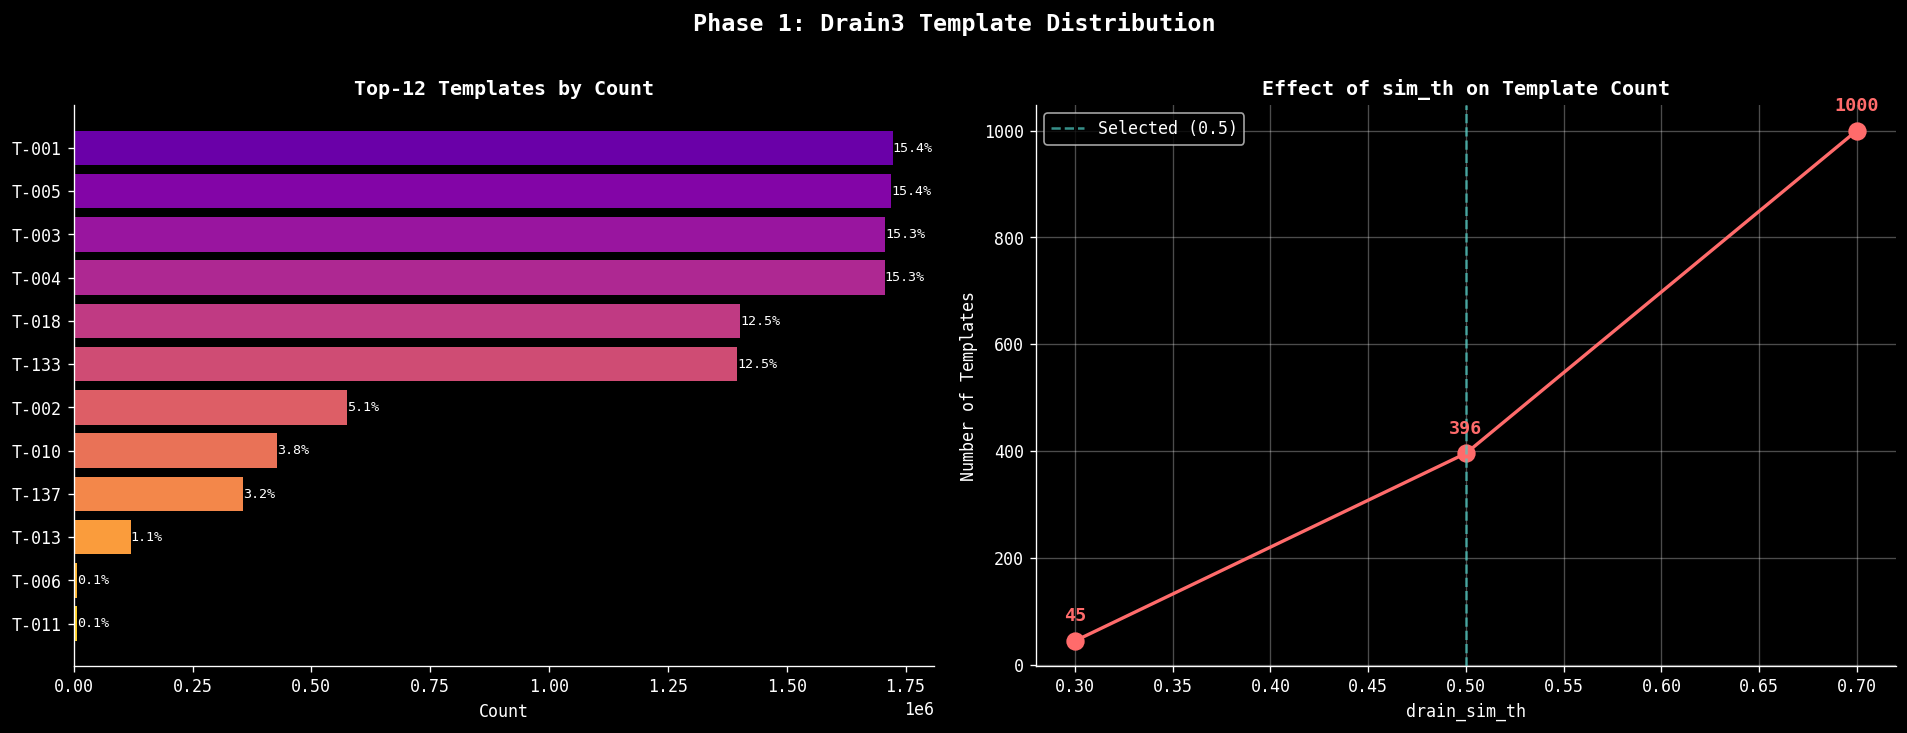

 Saved: assets/plot_template_distribution.png


In [8]:
# ── 1.5 Plot: Template Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 1: Drain3 Template Distribution', fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Top templates bar chart
ax = axes[0]
top_n = min(12, len(templates_df))
top_df = templates_df.head(top_n)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, top_n))
bars = ax.barh(
    [f'T-{tid:03d}' for tid in top_df['template_id']],
    top_df['count'],
    color=colors
)
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title(f'Top-{top_n} Templates by Count', fontweight='bold')
for bar, (_, row) in zip(bars, top_df.iterrows()):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{row["pct"]:.1f}%', va='center', fontsize=8, color='white')

# Plot 2: Tuning effect
ax2 = axes[1]
sim_vals = [r['sim_th'] for r in tuning_results]
n_tmpl   = [r['n_templates'] for r in tuning_results]
ax2.plot(sim_vals, n_tmpl, 'o-', color='#FF6B6B', linewidth=2, markersize=10)
for x, y in zip(sim_vals, n_tmpl):
    ax2.annotate(f'{y}', (x, y), textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=11, fontweight='bold', color='#FF6B6B')
ax2.axvline(x=0.5, color='#4ECDC4', linestyle='--', alpha=0.7, label='Selected (0.5)')
ax2.set_xlabel('drain_sim_th')
ax2.set_ylabel('Number of Templates')
ax2.set_title('Effect of sim_th on Template Count', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'plot_template_distribution.png', dpi=120, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print(" Saved: assets/plot_template_distribution.png")

---
## Phase 2: Anomaly Detection trên Log

**Mục tiêu:**
1. Tạo template count time series (window 5 phút)
2. Apply 3σ + Isolation Forest trên template count
3. Detect template spike + new template
4. Nếu có labels → tính precision/recall

In [9]:
# ── 2.1 Parse timestamps & tạo time series ──────────────────────────────────
print('=' * 60)
print('PHASE 2: ANOMALY DETECTION')
print('=' * 60)

# Load block-level labels (HDFS_v1 format: BlockId, Label)
block_label_map = {}  # blk_xxx -> 0 (Normal) or 1 (Anomaly)
if USE_LABELS:
    labels_df = pd.read_csv(LABELS_FILE)
    block_label_map = {
        row['BlockId']: 0 if row['Label'] == 'Normal' else 1
        for _, row in labels_df.iterrows()
    }
    n_anomaly_blocks = sum(v for v in block_label_map.values())
    print(f'Labels loaded: {len(block_label_map):,} blocks, '
          f'{n_anomaly_blocks:,} anomaly blocks '
          f'({n_anomaly_blocks/len(block_label_map)*100:.1f}%)')

# Parse timestamp + template_id + block_id from raw log lines
ts_pattern  = re.compile(r'(\d{6})\s+(\d{6})')
blk_pattern = re.compile(r'(blk_-?\d+)')

records = []
for raw_line, (ts_str, cluster_id, template) in zip(raw_lines, parsed_results):
    m = ts_pattern.search(raw_line)
    if not m:
        continue
    date_s, time_s = m.group(1), m.group(2)
    try:
        dt = datetime.strptime(date_s + time_s, '%y%m%d%H%M%S')
    except:
        continue
    # Extract block ID if present
    blk_m = blk_pattern.search(raw_line)
    blk_id = blk_m.group(1) if blk_m else None
    # Line-level label from block label map
    line_label = block_label_map.get(blk_id, 0) if blk_id else 0
    records.append({
        'timestamp'  : dt,
        'cluster_id' : cluster_id,
        'template'   : template,
        'block_id'   : blk_id,
        'label'      : line_label,
    })

logs_df = pd.DataFrame(records)
logs_df['timestamp'] = pd.to_datetime(logs_df['timestamp'])
logs_df = logs_df.sort_values('timestamp').reset_index(drop=True)

print(f'\nParsed records with timestamp: {len(logs_df):,}')
print(f'  Time range: {logs_df["timestamp"].min()} -> {logs_df["timestamp"].max()}')
print(f'  Duration  : {logs_df["timestamp"].max() - logs_df["timestamp"].min()}')
if USE_LABELS:
    print(f'  Anomaly lines: {logs_df["label"].sum():,} ({logs_df["label"].mean()*100:.1f}%)')


PHASE 2: ANOMALY DETECTION
Labels loaded: 575,061 blocks, 16,838 anomaly blocks (2.9%)

Parsed records with timestamp: 11,175,629
  Time range: 2008-11-09 20:35:18 -> 2008-11-11 11:16:28
  Duration  : 1 days 14:41:10
  Anomaly lines: 288,250 (2.6%)


In [10]:
# ── 2.2 Template Count Time Series (5-minute window) ─────────────────────────
WINDOW = '5min'

ts_df = (
    logs_df
    .groupby([pd.Grouper(key='timestamp', freq=WINDOW), 'cluster_id'])
    .size()
    .unstack(fill_value=0)
)

# Total log count per window
ts_df['TOTAL'] = ts_df.sum(axis=1)

print(f"\n Template Count Time Series:")
print(f"   Shape: {ts_df.shape} (windows × templates+1)")
print(f"   Window: {WINDOW}")
print(f"\nSample (first 5 windows):")
print(ts_df.head())


 Template Count Time Series:
   Shape: (465, 397) (windows × templates+1)
   Window: 5min

Sample (first 5 windows):
cluster_id              1     2     3     4     5   6  7  8  9   10  ...  388  \
timestamp                                                            ...        
2008-11-09 20:35:00  8112  2712  6908  6908  6913   7  4  3  3  407  ...    0   
2008-11-09 20:40:00  8514  2874  8423  8422  8423   0  0  0  0    0  ...    0   
2008-11-09 20:45:00  9425  3165  9285  9285  9308  25  0  1  1    0  ...    0   
2008-11-09 20:50:00  8519  2870  8436  8431  8435   4  0  1  1    0  ...    0   
2008-11-09 20:55:00  9382  3150  9271  9271  9292  22  0  0  0    0  ...    0   

cluster_id           389  390  391  392  393  394  395  396  TOTAL  
timestamp                                                           
2008-11-09 20:35:00    0    0    0    0    0    0    0    0  32186  
2008-11-09 20:40:00    0    0    0    0    0    0    0    0  37182  
2008-11-09 20:45:00    0    0    0    

In [11]:
# ── 2.3 Anomaly Detection: 3σ per Template ───────────────────────────────────
def detect_3sigma(series, window=20, n_sigma=3):
    """
    Rolling 3σ anomaly detection.
    Returns boolean Series: True = anomaly
    """
    roll_mean = series.rolling(window=window, min_periods=3).mean()
    roll_std  = series.rolling(window=window, min_periods=3).std()
    upper = roll_mean + n_sigma * roll_std
    lower = roll_mean - n_sigma * roll_std
    return (series > upper) | (series < lower), roll_mean, roll_std


# Apply 3σ on TOTAL count
total_series = ts_df['TOTAL']
anomaly_3sigma, roll_mean, roll_std = detect_3sigma(total_series)

print(f"3σ on TOTAL count:")
print(f"  Anomaly windows: {anomaly_3sigma.sum()} / {len(anomaly_3sigma)}")

# Also apply per top-5 template
template_cols = [c for c in ts_df.columns if c != 'TOTAL']
template_anomalies = {}
for col in template_cols:
    anom, _, _ = detect_3sigma(ts_df[col])
    if anom.sum() > 0:
        template_anomalies[col] = anom

print(f"  Templates with anomaly windows: {len(template_anomalies)}")
for tid, anom in template_anomalies.items():
    tmpl = templates_df[templates_df['template_id']==tid]['template'].values
    tmpl_str = tmpl[0][:60] + '...' if len(tmpl) > 0 and len(tmpl[0]) > 60 else (tmpl[0] if len(tmpl) > 0 else '?')
    print(f"    T-{tid:03d}: {anom.sum()} anomaly windows | {tmpl_str}")

3σ on TOTAL count:
  Anomaly windows: 21 / 465
  Templates with anomaly windows: 395
    T-001: 31 anomaly windows | Receiving block <*> src: <*> dest: <*>
    T-002: 31 anomaly windows | BLOCK* NameSystem.allocateBlock: <*> <*>
    T-003: 28 anomaly windows | PacketResponder <*> for block <*> <*>
    T-004: 28 anomaly windows | Received block <*> of size <*> from <*>
    T-005: 27 anomaly windows | BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is a...
    T-006: 17 anomaly windows | Received block <*> src: <*> dest: <*> of size <*>
    T-008: 11 anomaly windows | <*> Starting thread to transfer block <*> to <*> <*>
    T-009: 11 anomaly windows | BLOCK* ask <*> to replicate <*> to datanode(s) <*> <*>
    T-010: 16 anomaly windows | <*> Served block <*> to <*>
    T-011: 17 anomaly windows | BLOCK* ask <*> to replicate <*> to datanode(s) <*>
    T-012: 18 anomaly windows | <*> Starting thread to transfer block <*> to <*>
    T-013: 3 anomaly windows | Verification succeeded f

In [12]:
# ── 2.4 Anomaly Detection: Isolation Forest ──────────────────────────────────
# Feature: count của mỗi template → multivariate
X = ts_df[template_cols].values

if X.shape[0] > 10 and X.shape[1] > 0:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso_model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42
    )
    iso_preds = iso_model.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
    iso_scores = iso_model.score_samples(X_scaled)  # negative → more anomalous

    anomaly_iso = pd.Series(iso_preds == -1, index=ts_df.index)
    print(f"Isolation Forest (multivariate):")
    print(f"  Anomaly windows: {anomaly_iso.sum()} / {len(anomaly_iso)}")
    print(f"  Anomaly times:")
    for t in ts_df.index[anomaly_iso]:
        print(f"    {t}  total_count={ts_df.loc[t, 'TOTAL']}")
else:
    print("  Not enough data for Isolation Forest")
    anomaly_iso = pd.Series(False, index=ts_df.index)
    iso_scores  = np.zeros(len(ts_df))

Isolation Forest (multivariate):
  Anomaly windows: 24 / 465
  Anomaly times:
    2008-11-09 21:30:00  total_count=41904
    2008-11-10 10:40:00  total_count=43318
    2008-11-10 10:45:00  total_count=44308
    2008-11-10 10:50:00  total_count=40503
    2008-11-10 21:10:00  total_count=41121
    2008-11-10 21:15:00  total_count=41208
    2008-11-10 21:20:00  total_count=39918
    2008-11-10 22:15:00  total_count=38585
    2008-11-10 22:20:00  total_count=39067
    2008-11-10 22:25:00  total_count=39433
    2008-11-11 02:35:00  total_count=20372
    2008-11-11 03:35:00  total_count=32263
    2008-11-11 04:50:00  total_count=41580
    2008-11-11 04:55:00  total_count=42812
    2008-11-11 05:00:00  total_count=41528
    2008-11-11 07:00:00  total_count=40444
    2008-11-11 07:05:00  total_count=39404
    2008-11-11 07:10:00  total_count=38772
    2008-11-11 07:15:00  total_count=39346
    2008-11-11 07:20:00  total_count=41139
    2008-11-11 08:05:00  total_count=42411
    2008-11-11 08:1

In [13]:
# ── 2.5 New Template Detection ───────────────────────────────────────────────
print("\nNew Template Detection:")
print(f"  Total new templates created: {len(new_template_log)}")

if new_template_log:
    print("\n  Timeline of new template creation:")
    for entry in new_template_log:
        print(f"    Line {entry['line_index']:5d} | {entry['ts']} | T-{entry['cluster_id']:03d}: {entry['template'][:60]}")


New Template Detection:
  Total new templates created: 396

  Timeline of new template creation:
    Line     0 | 081109 203518 | T-001: Receiving block blk_-1608999687919862906 src: /10.250.19.102
    Line     1 | 081109 203518 | T-002: BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/j
    Line     4 | 081109 203519 | T-003: PacketResponder 1 for block blk_-1608999687919862906 termina
    Line     6 | 081109 203519 | T-004: Received block blk_-1608999687919862906 of size 91178 from /
    Line    10 | 081109 203519 | T-005: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.250.1
    Line    16 | 081109 203521 | T-006: Received block blk_-1608999687919862906 src: /10.251.215.16:
    Line    24 | 081109 203521 | T-007: 10.250.14.224:50010:Transmitted block blk_-16089996879198629
    Line    29 | 081109 203521 | T-008: 10.250.14.224:50010 Starting thread to transfer block blk_-1
    Line    30 | 081109 203521 | T-009: BLOCK* ask 10.250.14.224:50010 to replicate blk_-16089

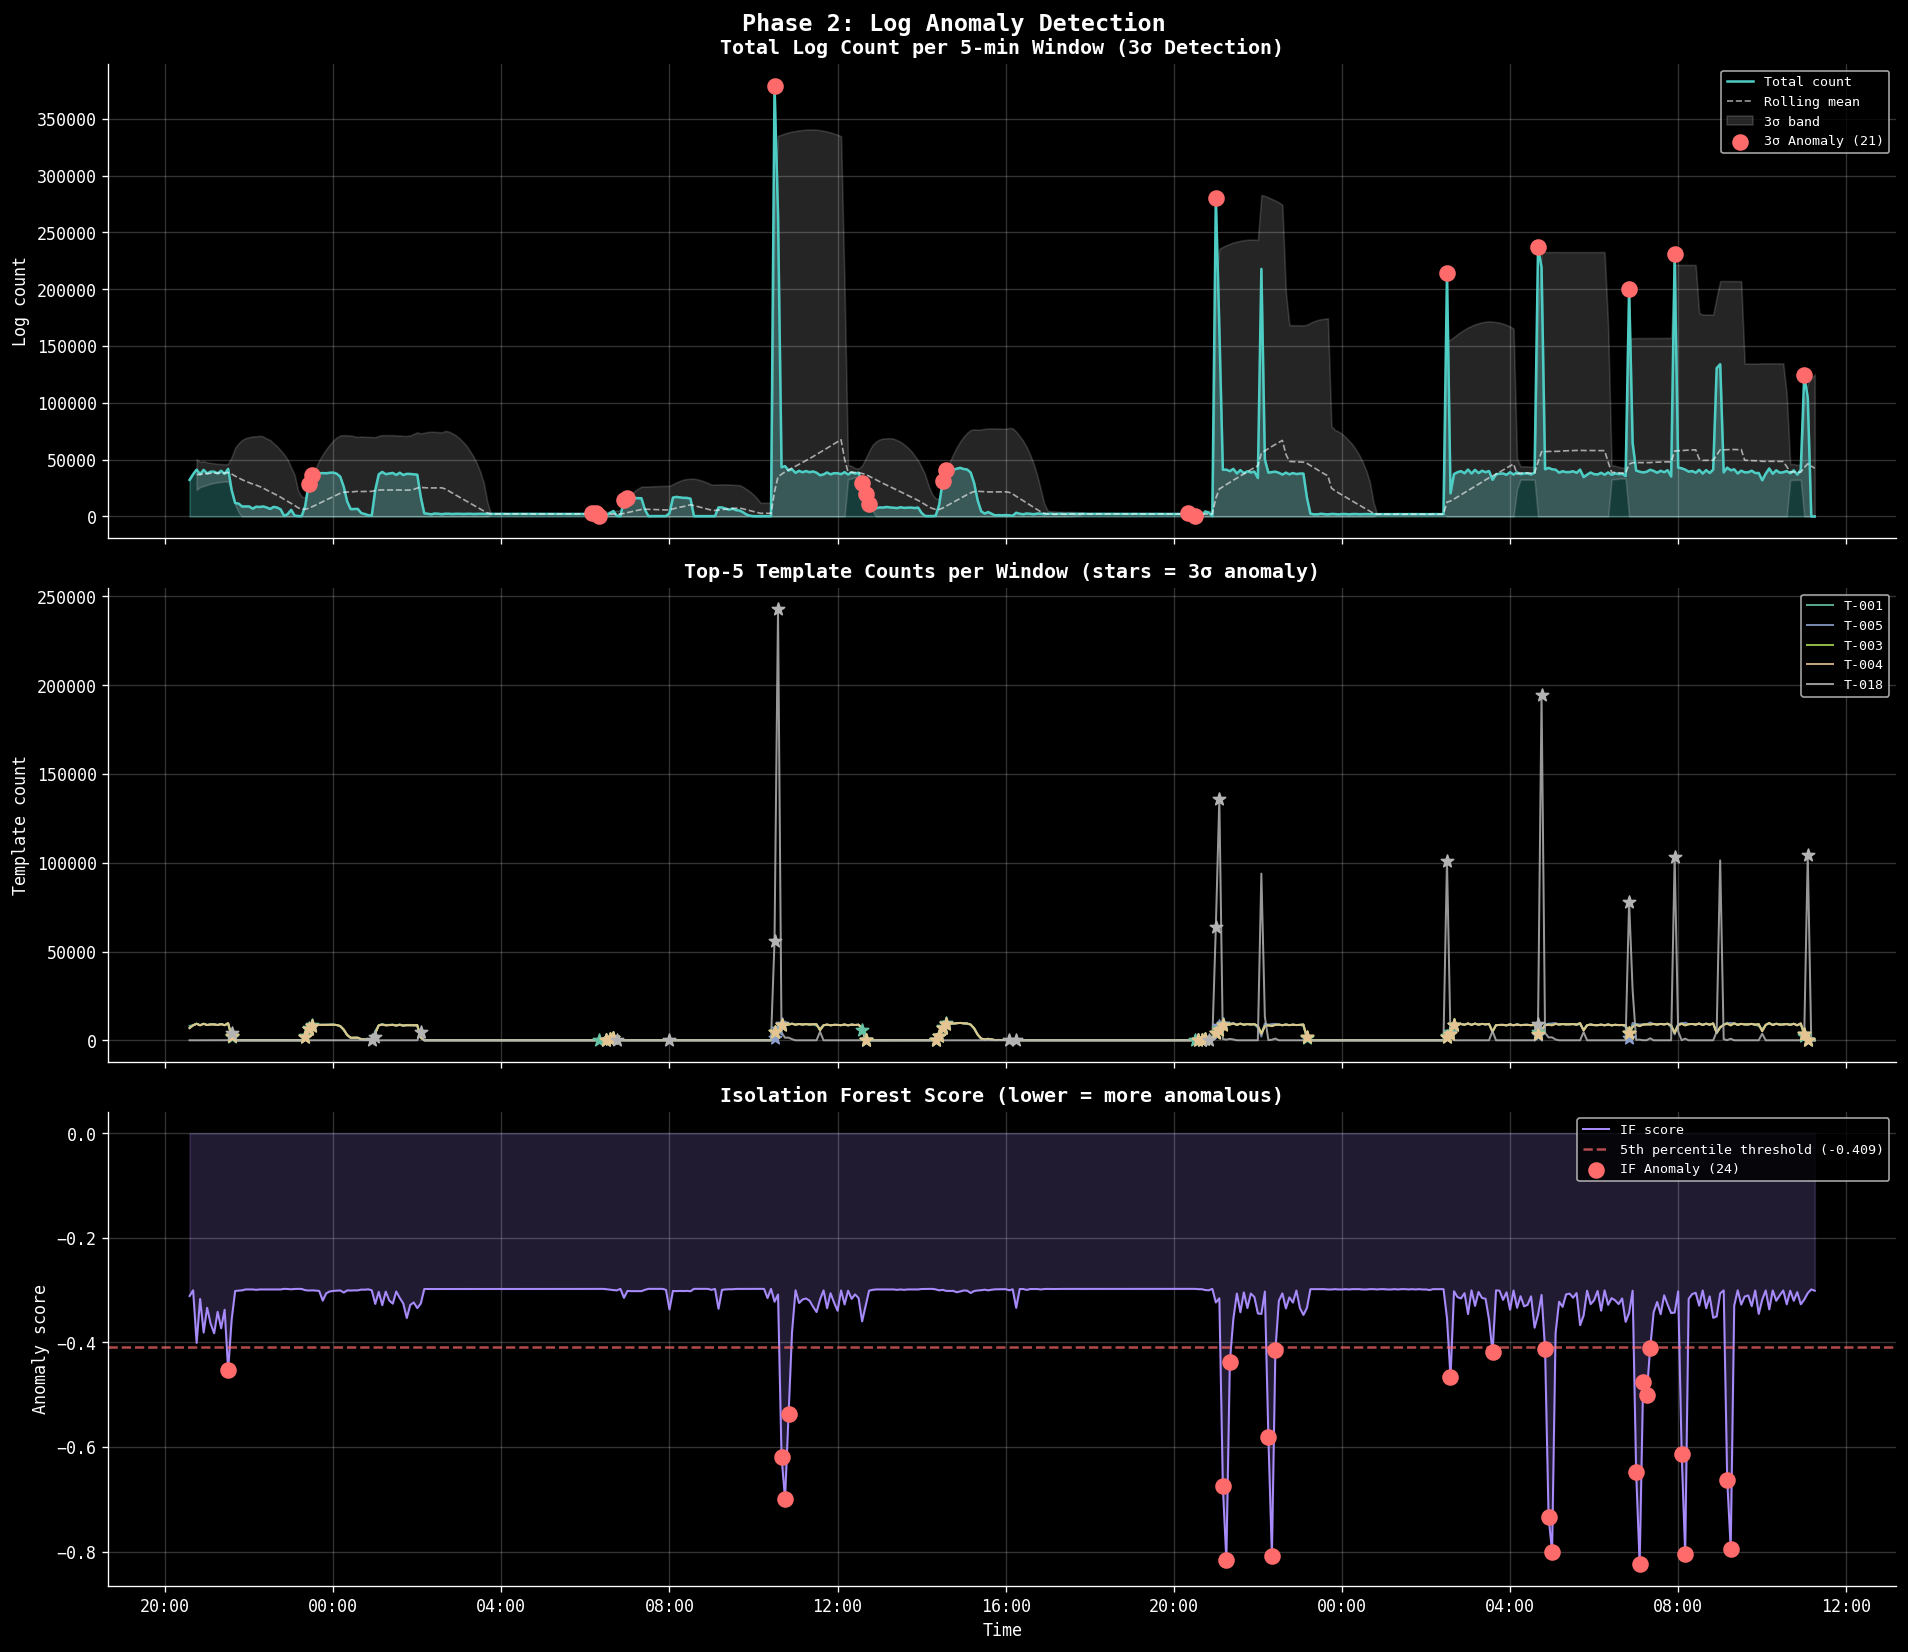

 Saved: assets/plot_anomaly_detection.png


In [14]:
# ── 2.6 Plot: Time Series + Anomaly ─────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Phase 2: Log Anomaly Detection', fontsize=14, fontweight='bold')

time_idx = ts_df.index

# Panel 1: Total log count per window
ax = axes[0]
ax.fill_between(time_idx, total_series, alpha=0.3, color='#4ECDC4')
ax.plot(time_idx, total_series, color='#4ECDC4', linewidth=1.5, label='Total count')
ax.plot(time_idx, roll_mean, color='white', linewidth=1, linestyle='--', alpha=0.6, label='Rolling mean')
upper_band = roll_mean + 3 * roll_std
lower_band = np.maximum(roll_mean - 3 * roll_std, 0)
ax.fill_between(time_idx, lower_band, upper_band, alpha=0.15, color='white', label='3σ band')

# Mark 3σ anomalies
anom_times = time_idx[anomaly_3sigma]
ax.scatter(anom_times, total_series[anomaly_3sigma],
           color='#FF6B6B', s=80, zorder=5, label=f'3σ Anomaly ({anomaly_3sigma.sum()})')
ax.set_title('Total Log Count per 5-min Window (3σ Detection)', fontweight='bold')
ax.set_ylabel('Log count')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.2)

# Panel 2: Per-template count (top 5)
ax2 = axes[1]
top5_templates = templates_df.head(5)['template_id'].tolist()
colors_p2 = plt.cm.Set2(np.linspace(0, 1, len(top5_templates)))
for tid, color in zip(top5_templates, colors_p2):
    if tid in ts_df.columns:
        ax2.plot(time_idx, ts_df[tid], linewidth=1.2, alpha=0.85,
                 label=f'T-{tid:03d}', color=color)
        # Highlight anomalies for this template
        if tid in template_anomalies:
            anom_t = time_idx[template_anomalies[tid]]
            ax2.scatter(anom_t, ts_df.loc[template_anomalies[tid], tid],
                        color=color, s=60, marker='*', zorder=5)
ax2.set_title('Top-5 Template Counts per Window (stars = 3σ anomaly)', fontweight='bold')
ax2.set_ylabel('Template count')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.2)

# Panel 3: Isolation Forest anomaly score
ax3 = axes[2]
ax3.plot(time_idx, iso_scores, color='#A78BFA', linewidth=1.2, label='IF score')
ax3.fill_between(time_idx, iso_scores, alpha=0.2, color='#A78BFA')
score_threshold = np.percentile(iso_scores, 5)
ax3.axhline(y=score_threshold, color='#FF6B6B', linestyle='--', alpha=0.7,
            label=f'5th percentile threshold ({score_threshold:.3f})')
ax3.scatter(time_idx[anomaly_iso], iso_scores[anomaly_iso],
            color='#FF6B6B', s=80, zorder=5, label=f'IF Anomaly ({anomaly_iso.sum()})')
ax3.set_title('Isolation Forest Score (lower = more anomalous)', fontweight='bold')
ax3.set_ylabel('Anomaly score')
ax3.set_xlabel('Time')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(alpha=0.2)

# Format x-axis
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'plot_anomaly_detection.png', dpi=120, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print(" Saved: assets/plot_anomaly_detection.png")

In [15]:
# ── 2.7 Precision / Recall (block-based labels) ─────────────────────────────
if USE_LABELS and len(logs_df) > 0:
    from sklearn.metrics import precision_score, recall_score, f1_score

    # Aggregate line-level labels to 5-min window level
    # A window is anomalous if ANY line in it has anomaly block
    window_labels = (
        logs_df.groupby(pd.Grouper(key='timestamp', freq=WINDOW))['label']
        .max()  # 1 if any anomaly line in window, else 0
    )

    # Align with ts_df index
    common_idx = ts_df.index.intersection(window_labels.index)
    if len(common_idx) > 5:
        y_true = window_labels.loc[common_idx].values

        # 3σ predictions
        y_3sigma = anomaly_3sigma.loc[common_idx].astype(int).values

        # IF predictions
        y_iso = anomaly_iso.loc[common_idx].astype(int).values

        print('\n' + '='*60)
        print('EVALUATION vs GROUND TRUTH LABELS (block-based)')
        print('='*60)
        print(f'  Windows evaluated   : {len(common_idx)}')
        print(f'  Anomaly windows (true): {int(y_true.sum())}\n')

        for name, y_pred in [('3sigma Detection', y_3sigma), ('Isolation Forest', y_iso)]:
            p = precision_score(y_true, y_pred, zero_division=0)
            r = recall_score(y_true, y_pred, zero_division=0)
            f = f1_score(y_true, y_pred, zero_division=0)
            print(f'  [{name}]')
            print(f'    Precision : {p:.3f}')
            print(f'    Recall    : {r:.3f}')
            print(f'    F1        : {f:.3f}')
            print(f'    Predicted anomaly windows: {int(y_pred.sum())}')
            print()
    else:
        print('Not enough overlapping windows for evaluation')
else:
    print('No labels available — skipping precision/recall')



EVALUATION vs GROUND TRUTH LABELS (block-based)
  Windows evaluated   : 465
  Anomaly windows (true): 463

  [3sigma Detection]
    Precision : 1.000
    Recall    : 0.045
    F1        : 0.087
    Predicted anomaly windows: 21

  [Isolation Forest]
    Precision : 1.000
    Recall    : 0.052
    F1        : 0.099
    Predicted anomaly windows: 24



---
## Phase 3: Embedding + Cross-signal

**Mục tiêu:**
1. TF-IDF trên templates → similarity matrix → clusters
2. Inject "lạ" log → detect new template
3. Mô phỏng cross-signal: metric anomaly → filter log → find template spike

In [16]:
# ── 3.1 TF-IDF Template Embedding ───────────────────────────────────────────
print("=" * 60)
print("PHASE 3: EMBEDDING + CROSS-SIGNAL")
print("=" * 60)

all_templates = [c.get_template() for c in miner.drain.clusters]
all_template_ids = [c.cluster_id for c in miner.drain.clusters]

if len(all_templates) < 2:
    print("⚠️  Need ≥2 templates for similarity analysis")
else:
    # TF-IDF vectorize
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1,
        token_pattern=r'(?u)\b[a-zA-Z_$][a-zA-Z0-9_$]*\b'  # Skip <*> tokens
    )
    tfidf_matrix = vectorizer.fit_transform(all_templates)
    sim_matrix   = cosine_similarity(tfidf_matrix)

    print(f"\n TF-IDF matrix: {tfidf_matrix.shape}")
    print(f"   Vocab size: {len(vectorizer.vocabulary_)}")

    # Print top similar pairs
    print("\n🔗 Most Similar Template Pairs:")
    pairs = []
    n = len(all_templates)
    for i in range(n):
        for j in range(i+1, n):
            pairs.append((sim_matrix[i,j], all_template_ids[i], all_template_ids[j],
                          all_templates[i][:40], all_templates[j][:40]))
    pairs.sort(reverse=True)
    for sim, tid1, tid2, t1, t2 in pairs[:5]:
        print(f"  T-{tid1:03d} ↔ T-{tid2:03d}: sim={sim:.3f}")
        print(f"    '{t1}...'")
        print(f"    '{t2}...'")

PHASE 3: EMBEDDING + CROSS-SIGNAL

 TF-IDF matrix: (396, 298)
   Vocab size: 298

🔗 Most Similar Template Pairs:
  T-376 ↔ T-382: sim=1.000
    '<*> block <*> to /10.251.199.159:50010...'
    '<*> block <*> to /10.251.39.192:50010...'
  T-370 ↔ T-382: sim=1.000
    '<*> block <*> to /10.251.42.9:50010...'
    '<*> block <*> to /10.251.39.192:50010...'
  T-370 ↔ T-376: sim=1.000
    '<*> block <*> to /10.251.42.9:50010...'
    '<*> block <*> to /10.251.199.159:50010...'
  T-364 ↔ T-382: sim=1.000
    '<*> block <*> to /10.250.15.198:50010...'
    '<*> block <*> to /10.251.39.192:50010...'
  T-364 ↔ T-376: sim=1.000
    '<*> block <*> to /10.250.15.198:50010...'
    '<*> block <*> to /10.251.199.159:50010...'


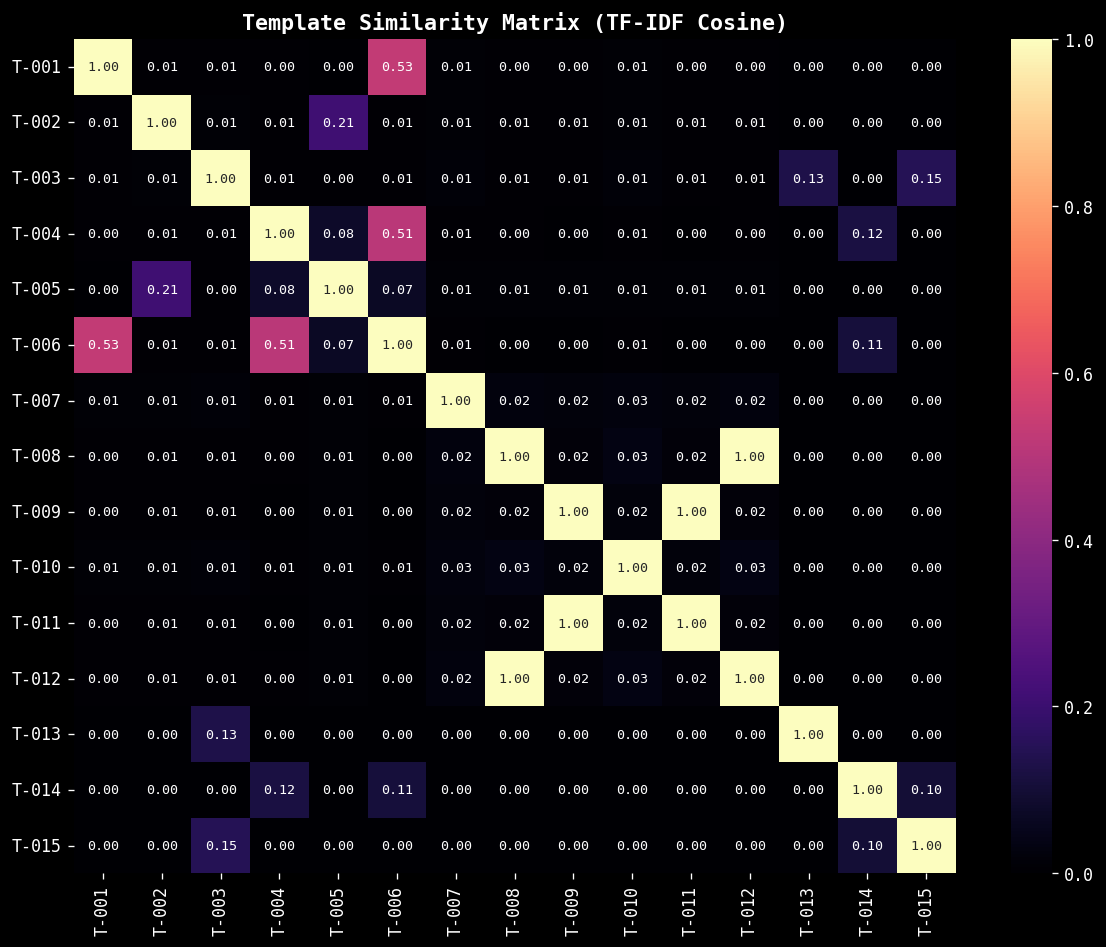

 Saved: assets/plot_similarity_matrix.png


In [17]:
# ── 3.2 Plot: Similarity Heatmap ────────────────────────────────────────────
if len(all_templates) >= 2:
    n_show = min(len(all_templates), 15)
    labels_hm = [f'T-{tid:03d}' for tid in all_template_ids[:n_show]]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        sim_matrix[:n_show, :n_show],
        xticklabels=labels_hm,
        yticklabels=labels_hm,
        annot=True, fmt='.2f',
        cmap='magma',
        vmin=0, vmax=1,
        ax=ax,
        annot_kws={'size': 8}
    )
    ax.set_title('Template Similarity Matrix (TF-IDF Cosine)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / 'plot_similarity_matrix.png', dpi=120, bbox_inches='tight',
                facecolor='#1a1a2e')
    plt.show()
    print(" Saved: assets/plot_similarity_matrix.png")

In [18]:
# ── 3.3 New Template Injection ───────────────────────────────────────────────
print("\n--- Injecting Anomalous Log Lines ---")

strange_logs = [
    "CRITICAL: Memory corruption detected in heap segment 0x7fff8b2d at offset 1024 bytes",
    "SQL injection attempt detected from 192.168.99.1 query: SELECT * FROM users WHERE 1=1",
    "Kernel panic: unable to handle kernel NULL pointer dereference at 000000000000000f",
    "Receiving block blk_7291837465 src: /10.5.0.1:50010 dest: /10.5.0.2:50010",  # Similar to existing
]

known_templates_before = set(c.get_template() for c in miner.drain.clusters)
n_before = len(miner.drain.clusters)

print(f"Templates before injection: {n_before}")

for log in strange_logs:
    result = miner.add_log_message(log)
    change = result['change_type']
    new_tmpl = result['template_mined']
    is_new = (change == 'cluster_created')
    icon = ' NEW' if is_new else '✓ matched'
    print(f"\n  {icon}")
    print(f"  Input   : {log[:70]}")
    print(f"  Template: {new_tmpl[:70]}")
    print(f"  Change  : {change}")

n_after = len(miner.drain.clusters)
print(f"\nTemplates after injection: {n_after}  (+{n_after - n_before} new)")


--- Injecting Anomalous Log Lines ---
Templates before injection: 396

   NEW
  Input   : CRITICAL: Memory corruption detected in heap segment 0x7fff8b2d at off
  Template: CRITICAL: Memory corruption detected in heap segment 0x7fff8b2d at off
  Change  : cluster_created

   NEW
  Input   : SQL injection attempt detected from 192.168.99.1 query: SELECT * FROM 
  Template: SQL injection attempt detected from 192.168.99.1 query: SELECT * FROM 
  Change  : cluster_created

   NEW
  Input   : Kernel panic: unable to handle kernel NULL pointer dereference at 0000
  Template: Kernel panic: unable to handle kernel NULL pointer dereference at 0000
  Change  : cluster_created

  ✓ matched
  Input   : Receiving block blk_7291837465 src: /10.5.0.1:50010 dest: /10.5.0.2:50
  Template: Receiving block <*> src: <*> dest: <*>
  Change  : none

Templates after injection: 399  (+3 new)


In [19]:
# ── 3.4 Cross-signal Analysis: Metric Anomaly → Log ─────────────────────────
print("\n--- Cross-Signal Analysis: Metric + Log ---")
print("Simulating: latency spike detected at a specific time window")
print("Finding correlated log templates...\n")

# Simulate metric anomaly time = peak anomaly time from our detection
if anomaly_3sigma.sum() > 0 or anomaly_iso.sum() > 0:
    # Take the window with highest total count as our "metric anomaly" time
    peak_window = ts_df['TOTAL'].idxmax()
else:
    peak_window = ts_df.index[len(ts_df)//4]  # fallback: 25% point

print(f" Metric anomaly detected at: {peak_window}")

# Filter logs within ±10 minutes
window_start = peak_window - pd.Timedelta(minutes=10)
window_end   = peak_window + pd.Timedelta(minutes=10)

window_logs = logs_df[
    (logs_df['timestamp'] >= window_start) & 
    (logs_df['timestamp'] <= window_end)
]

print(f"   Time window: {window_start} to {window_end}")
print(f"   Log lines in window: {len(window_logs):,}")

if len(window_logs) > 0:
    # Template distribution in anomaly window
    window_template_counts = window_logs['cluster_id'].value_counts()
    
    # Compare with baseline (all time)
    baseline_counts = logs_df['cluster_id'].value_counts(normalize=True)
    window_counts_norm = window_template_counts / window_logs.shape[0]
    
    print(f"\n Top Templates During Anomaly Window vs Baseline:")
    print(f"{'Template':<12} {'Window%':>10} {'Baseline%':>12} {'Ratio':>8}")
    print("-" * 46)
    
    for tid in window_template_counts.head(8).index:
        w_pct = window_counts_norm.get(tid, 0) * 100
        b_pct = baseline_counts.get(tid, 0) * 100
        ratio = w_pct / b_pct if b_pct > 0 else float('inf')
        flag = " ← SPIKE" if ratio > 2 else ""
        print(f"  T-{tid:03d}      {w_pct:8.1f}%   {b_pct:8.1f}%   {ratio:6.2f}x{flag}")
    
    # Most anomalous template = highest ratio
    if len(window_template_counts) > 0:
        top_tid = window_template_counts.index[0]
        top_tmpl = templates_df[templates_df['template_id']==top_tid]['template'].values
        if len(top_tmpl) > 0:
            print(f"\n Root Cause Candidate:")
            print(f"   Template: T-{top_tid:03d}")
            print(f"   Message : {top_tmpl[0]}")
            print(f"   Count in window: {window_template_counts.iloc[0]}")


--- Cross-Signal Analysis: Metric + Log ---
Simulating: latency spike detected at a specific time window
Finding correlated log templates...

 Metric anomaly detected at: 2008-11-10 10:30:00
   Time window: 2008-11-10 10:20:00 to 2008-11-10 10:40:00
   Log lines in window: 645,117

 Top Templates During Anomaly Window vs Baseline:
Template        Window%    Baseline%    Ratio
----------------------------------------------
  T-133          47.4%       12.5%     3.80x ← SPIKE
  T-018          46.3%       12.5%     3.69x ← SPIKE
  T-001           1.5%       15.4%     0.10x
  T-003           1.3%       15.3%     0.09x
  T-004           1.3%       15.3%     0.09x
  T-005           1.2%       15.4%     0.08x
  T-002           0.5%        5.1%     0.10x
  T-134           0.2%        0.0%     3.60x ← SPIKE

 Root Cause Candidate:
   Template: T-133
   Message : BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
   Count in window: 306004


---
## Phase 4: Mini Log Analyzer Script

Build `log_analyzer.py` — script nhận log file làm input, output:
- Tổng số dòng, số template unique
- Top-5 templates
- Template spike trong 1h gần nhất
- New templates

Cell này cũng chạy analyzer trên dataset hiện tại.

In [20]:
# ── 4.1 Write log_analyzer.py ────────────────────────────────────────────────
script = '''#!/usr/bin/env python3
"""
log_analyzer.py — Mini Log Analyzer
Usage: python log_analyzer.py <logfile>

Output:
  - Total lines & unique templates
  - Top-5 templates (count + %)
  - Spike templates in last 1 hour
  - New templates (first appeared in last 1 hour)
"""
import sys, re, os
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timedelta

try:
    from drain3 import TemplateMiner
    from drain3.template_miner_config import TemplateMinerConfig
except ImportError:
    print("ERROR: drain3 not installed. Run: pip install drain3")
    sys.exit(1)


BANNER = """
╔══════════════════════════════════════════════════════════════╗
║            Mini Log Analyzer  (W1-D2 AIOps)               ║
╚══════════════════════════════════════════════════════════════╝
"""


def preprocess(line: str) -> str:
    line = line.strip()
    line = re.sub(r"^\\d{6}\\s+\\d{6}\\s+", "", line)
    line = re.sub(r"\\[\\d{4}-\\d{2}-\\d{2}T[\\d:.Z]+\\]\\s*", "", line)
    line = re.sub(r"\\b(INFO|WARN|WARNING|ERROR|DEBUG|CRITICAL|FATAL)\\b\\s*", "", line)
    line = re.sub(r"[\\w.$]+:\\s*", "", line, count=1)
    return line.strip()


def parse_timestamp(line: str):
    m = re.search(r"(\\d{6})\\s+(\\d{6})", line)
    if m:
        try:
            return datetime.strptime(m.group(1) + m.group(2), "%y%m%d%H%M%S")
        except:
            pass
    m2 = re.search(r"(\\d{4}-\\d{2}-\\d{2}T\\d{2}:\\d{2}:\\d{2})", line)
    if m2:
        try:
            return datetime.strptime(m2.group(1), "%Y-%m-%dT%H:%M:%S")
        except:
            pass
    return None


def analyze(logfile: str, sim_th: float = 0.5):
    path = Path(logfile)
    if not path.exists():
        print(f"ERROR: File not found: {logfile}")
        sys.exit(1)

    # -- Setup Drain3 --
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th = sim_th
    cfg.drain_depth  = 4
    cfg.parametrize_numeric_tokens = True
    miner = TemplateMiner(config=cfg)

    # -- Parse --
    records = []   # (timestamp, cluster_id, template, is_new)
    n_total = 0
    n_skip  = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            n_total += 1
            content = preprocess(raw)
            if not content:
                n_skip += 1
                continue
            ts = parse_timestamp(raw)
            result = miner.add_log_message(content)
            is_new = (result["change_type"] == "cluster_created")
            records.append((ts, result["cluster_id"], result["template_mined"], is_new))

    # -- Stats --
    n_parsed    = len(records)
    n_templates = len(miner.drain.clusters)

    # Template counts
    tmpl_counts = Counter(r[1] for r in records)
    tmpl_text   = {c.cluster_id: c.get_template() for c in miner.drain.clusters}

    # -- Time-based analysis --
    valid_ts = [(ts, cid, tmpl, is_new) for ts, cid, tmpl, is_new in records if ts is not None]
    spike_templates = []
    new_in_last_hour = []

    if valid_ts:
        max_ts = max(r[0] for r in valid_ts)
        cutoff = max_ts - timedelta(hours=1)

        recent = [(ts, cid, tmpl, is_new) for ts, cid, tmpl, is_new in valid_ts if ts >= cutoff]
        older  = [(ts, cid, tmpl, is_new) for ts, cid, tmpl, is_new in valid_ts if ts < cutoff]

        recent_counts = Counter(r[1] for r in recent)
        older_counts  = Counter(r[1] for r in older)
        older_total   = max(len(older), 1)
        recent_total  = max(len(recent), 1)

        # Spike: recent rate / baseline rate > 3
        for cid, cnt in recent_counts.items():
            recent_rate   = cnt / recent_total
            baseline_rate = older_counts.get(cid, 0) / older_total
            if baseline_rate > 0:
                ratio = recent_rate / baseline_rate
                if ratio > 3:
                    spike_templates.append((cid, cnt, ratio, tmpl_text.get(cid, "?")))

        # New templates in last hour
        new_in_last_hour = list(set(
            (cid, tmpl) for ts, cid, tmpl, is_new in recent if is_new
        ))

    # -- Print Results --
    print(BANNER)
    print(f"  File    : {path.name}")
    print(f"  Size    : {path.stat().st_size / 1024:.1f} KB")
    print()

    print("┌─────────────────────────────────────────┐")
    print("│  SUMMARY                                │")
    print("├─────────────────────────────────────────┤")
    print(f"│  Total lines      : {n_total:<20,}│")
    print(f"│  Parsed lines     : {n_parsed:<20,}│")
    print(f"│  Unique templates : {n_templates:<20,}│")
    print("└─────────────────────────────────────────┘")

    print()
    print("  TOP-5 TEMPLATES")
    print("  " + "-" * 64)
    for rank, (cid, cnt) in enumerate(tmpl_counts.most_common(5), 1):
        pct = cnt / n_parsed * 100 if n_parsed > 0 else 0
        tmpl_str = tmpl_text.get(cid, "?")[:55]
        bar = "█" * int(pct / 2)
        print(f"  #{rank} T-{cid:03d}  {cnt:6,}  ({pct:5.1f}%)  {bar}")
        print(f"       {tmpl_str}")

    print()
    print("  SPIKE TEMPLATES (last 1h vs baseline, ratio > 3x)")
    print("  " + "-" * 64)
    if spike_templates:
        for cid, cnt, ratio, tmpl in sorted(spike_templates, key=lambda x: -x[2]):
            print(f"  🔥 T-{cid:03d}  count={cnt}  ratio={ratio:.1f}x")
            print(f"       {tmpl[:60]}")
    else:
        print("  ✅ No spike detected")

    print()
    print("  NEW TEMPLATES (first appeared in last 1h)")
    print("  " + "-" * 64)
    if new_in_last_hour:
        for cid, tmpl in new_in_last_hour:
            print(f"  ⚡ T-{cid:03d}: {tmpl[:60]}")
    else:
        print("  ✅ No new templates")

    print()
    return {
        "total_lines": n_total,
        "n_templates": n_templates,
        "top5": tmpl_counts.most_common(5),
        "spike_templates": spike_templates,
        "new_templates": new_in_last_hour,
    }


if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python log_analyzer.py <logfile>")
        sys.exit(1)
    analyze(sys.argv[1])
'''

with open('log_analyzer.py', 'w', encoding='utf-8') as f:
    f.write(script)

print("✅ Written: log_analyzer.py")

✅ Written: log_analyzer.py


In [21]:
# ── 4.2 Run Analyzer In-Notebook ────────────────────────────────────────────
# Run the same logic inline (so it works without subprocess)

def run_inline_analyzer(logfile, sim_th=0.5):
    """Same as log_analyzer.py but runs inline in notebook."""
    from pathlib import Path
    from collections import Counter
    from datetime import datetime, timedelta

    path = Path(logfile)
    cfg = TemplateMinerConfig()
    cfg.drain_sim_th = sim_th
    cfg.drain_depth  = 4
    cfg.parametrize_numeric_tokens = True
    m2 = TemplateMiner(config=cfg)

    records2 = []
    n_total2 = 0

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for raw in f:
            n_total2 += 1
            content = preprocess_log_line(raw)
            if not content:
                continue
            ts_match = re.match(r'(\d{6})\s+(\d{6})', raw)
            ts = None
            if ts_match:
                try:
                    ts = datetime.strptime(ts_match.group(1) + ts_match.group(2), '%y%m%d%H%M%S')
                except:
                    pass
            result = m2.add_log_message(content)
            is_new = (result['change_type'] == 'cluster_created')
            records2.append((ts, result['cluster_id'], result['template_mined'], is_new))

    n_parsed2   = len(records2)
    n_templates2= len(m2.drain.clusters)
    tmpl_counts2= Counter(r[1] for r in records2)
    tmpl_text2  = {c.cluster_id: c.get_template() for c in m2.drain.clusters}

    # Spike & new
    valid2 = [(ts, cid, tmpl, is_new) for ts, cid, tmpl, is_new in records2 if ts is not None]
    spike2, new2 = [], []
    if valid2:
        max_ts2 = max(r[0] for r in valid2)
        cutoff2 = max_ts2 - timedelta(hours=1)
        recent2 = [r for r in valid2 if r[0] >= cutoff2]
        older2  = [r for r in valid2 if r[0] < cutoff2]
        rc2 = Counter(r[1] for r in recent2)
        oc2 = Counter(r[1] for r in older2)
        for cid, cnt in rc2.items():
            rr = cnt / max(len(recent2), 1)
            br = oc2.get(cid, 0) / max(len(older2), 1)
            if br > 0 and rr / br > 3:
                spike2.append((cid, cnt, rr/br, tmpl_text2.get(cid, '?')))
        new2 = list(set((r[1], r[2]) for r in recent2 if r[3]))

    # Print
    sep = '═' * 65
    print(f"\n{sep}")
    print(f"  LOG ANALYZER — {path.name}")
    print(sep)
    print(f"  Total lines      : {n_total2:,}")
    print(f"  Parsed lines     : {n_parsed2:,}")
    print(f"  Unique templates : {n_templates2}")

    print(f"\n  TOP-5 TEMPLATES:")
    for rank, (cid, cnt) in enumerate(tmpl_counts2.most_common(5), 1):
        pct = cnt / n_parsed2 * 100 if n_parsed2 > 0 else 0
        bar = '█' * int(pct / 2)
        tmpl_s = tmpl_text2.get(cid, '?')[:55]
        print(f"  #{rank} [T-{cid:03d}] {cnt:5,} ({pct:.1f}%) {bar}")
        print(f"       {tmpl_s}")

    print(f"\n  SPIKE TEMPLATES (ratio > 3x in last 1h):")
    if spike2:
        for cid, cnt, ratio, tmpl in sorted(spike2, key=lambda x: -x[2]):
            print(f"  🔥 T-{cid:03d}  count={cnt}  ratio={ratio:.1f}x  {tmpl[:50]}")
    else:
        print("  ✅ None")

    print(f"\n  NEW TEMPLATES (last 1h):")
    if new2:
        for cid, tmpl in new2:
            print(f"  ⚡ T-{cid:03d}: {tmpl[:60]}")
    else:
        print("  ✅ None")

    return {'total': n_total2, 'templates': n_templates2, 'top5': tmpl_counts2.most_common(5)}


print("=" * 60)
print("PHASE 4: MINI LOG ANALYZER")
print("=" * 60)

result_hdfs = run_inline_analyzer(LOG_FILE)

PHASE 4: MINI LOG ANALYZER

═════════════════════════════════════════════════════════════════
  LOG ANALYZER — HDFS.log
═════════════════════════════════════════════════════════════════
  Total lines      : 11,175,629
  Parsed lines     : 11,175,629
  Unique templates : 396

  TOP-5 TEMPLATES:
  #1 [T-001] 1,723,232 (15.4%) ███████
       Receiving block <*> src: <*> dest: <*>
  #2 [T-005] 1,719,741 (15.4%) ███████
       BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>
  #3 [T-003] 1,706,728 (15.3%) ███████
       PacketResponder <*> for block <*> <*>
  #4 [T-004] 1,706,514 (15.3%) ███████
       Received block <*> of size <*> from <*>
  #5 [T-018] 1,402,047 (12.5%) ██████
       Deleting block <*> file <*>

  SPIKE TEMPLATES (ratio > 3x in last 1h):
  🔥 T-396  count=1  ratio=9.3x  10.251.123.33:50010:Transmitted block <*> to <*>
  🔥 T-368  count=1  ratio=3.1x  10.251.71.68:50010:Transmitted block <*> to <*>

  NEW TEMPLATES (last 1h):
  ✅ None


In [26]:
# ── 4.3 Generate & Test on a 2nd Dataset ────────────────────────────────────
# Generate BGL-style (supercomputer) log for comparison
BGL_FILE = DATASET_DIR / 'BGL_2k.log'

def generate_bgl_log(n=3000, seed=99):
    """Synthetic BGL supercomputer log."""
    rng2 = np.random.default_rng(seed)
    nodes = [f'R{rng2.integers(0,4):02d}-M0-N{rng2.integers(0,16):02d}-J00-U01' for _ in range(20)]
    
    templates = [
        lambda: f'instruction cache parity error corrected on node {nodes[rng2.integers(0,20)]}',
        lambda: f'ciod: failed to read message prefix on CioStream socket to {rng2.integers(0,255)}.{rng2.integers(0,255)}.{rng2.integers(0,255)}.{rng2.integers(0,255)}:{rng2.integers(1024,65535)}',
        lambda: f'data cache: {rng2.integers(1,100)} correctable errors on node {nodes[rng2.integers(0,20)]}',
        lambda: f'rts: kernel terminating with status {rng2.integers(100,200)} on node {nodes[rng2.integers(0,20)]}',
        lambda: f'MPI_Allreduce reported error rank {rng2.integers(0,1024)} out of {rng2.integers(1024,4096)}',
        lambda: f'job {rng2.integers(100000,999999)} ended with exit code {rng2.integers(0,255)}',
        lambda: f'temperature high on node {nodes[rng2.integers(0,20)]} cpu{rng2.integers(0,4)}: {rng2.integers(75,95)}C',
    ]
    
    base = datetime(2024, 1, 16, 0, 0, 0)
    lines = []
    t = base
    for i in range(n):
        t += timedelta(seconds=rng2.uniform(1, 10))
        tmpl = templates[rng2.integers(0, len(templates))]
        msg = tmpl()
        ts = t.strftime('%y%m%d %H%M%S')
        lvl = rng2.choice(['INFO', 'WARN', 'ERROR', 'FATAL'], p=[0.7, 0.15, 0.10, 0.05])
        lines.append(f'{ts} {lvl} bgl.kernel: {msg}\n')
    return lines


if not BGL_FILE.exists():
    bgl_lines = generate_bgl_log(3000)
    with open(BGL_FILE, 'w', encoding='utf-8') as f:
        f.writelines(bgl_lines)
    print(f" Generated BGL synthetic log: {len(bgl_lines):,} lines")
else:
    print(f" Found existing BGL log")

result_bgl = run_inline_analyzer(BGL_FILE)

 Found existing BGL log

═════════════════════════════════════════════════════════════════
  LOG ANALYZER — BGL_2k.log
═════════════════════════════════════════════════════════════════
  Total lines      : 2,000
  Parsed lines     : 2,000
  Unique templates : 164

  TOP-5 TEMPLATES:
  #1 [T-081]   180 (9.0%) ████
       - <*> 2005.07.09 <*> <*> <*> RAS KERNEL generating <*>
  #2 [T-093]   121 (6.0%) ███
       - <*> <*> <*> <*> <*> RAS KERNEL <*> floating point ali
  #3 [T-002]   109 (5.5%) ██
       - <*> <*> <*> <*> <*> RAS KERNEL <*> double-hummer alig
  #4 [T-086]    87 (4.3%) ██
       - <*> 2005.07.13 <*> <*> <*> RAS KERNEL generating <*>
  #5 [T-150]    71 (3.5%) █
       - <*> 2005.12.01 <*> <*> <*> RAS KERNEL <*> total inter

  SPIKE TEMPLATES (ratio > 3x in last 1h):
  ✅ None

  NEW TEMPLATES (last 1h):
  ✅ None


In [27]:
# ── 4.4 Compare Two Datasets ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  DATASET COMPARISON: HDFS vs BGL")
print("=" * 65)
print(f"  {'Metric':<30} {'HDFS':>15} {'BGL':>15}")
print(f"  {'-'*60}")
print(f"  {'Total lines':<30} {result_hdfs['total']:>15,} {result_bgl['total']:>15,}")
print(f"  {'Unique templates':<30} {result_hdfs['templates']:>15} {result_bgl['templates']:>15}")
ratio_hdfs = result_hdfs['total'] / max(result_hdfs['templates'], 1)
ratio_bgl  = result_bgl['total']  / max(result_bgl['templates'], 1)
print(f"  {'Avg lines/template':<30} {ratio_hdfs:>15.0f} {ratio_bgl:>15.0f}")

print()
print("   Nhận xét:")
if result_hdfs['templates'] > result_bgl['templates']:
    print(f"  HDFS có nhiều template hơn BGL ({result_hdfs['templates']} vs {result_bgl['templates']})")
    print("  Vì HDFS log đa dạng hơn: block operations, network connections,")
    print("  file system events → nhiều pattern khác nhau.")
    print("  BGL log chủ yếu là hardware error + job management → ít pattern hơn.")
else:
    print(f"  BGL có nhiều template hơn HDFS ({result_bgl['templates']} vs {result_hdfs['templates']})")
    print("  Vì BGL supercomputer log phức tạp hơn với nhiều hardware event khác nhau.")


  DATASET COMPARISON: HDFS vs BGL
  Metric                                    HDFS             BGL
  ------------------------------------------------------------
  Total lines                         11,175,629           2,000
  Unique templates                           396             164
  Avg lines/template                       28221              12

   Nhận xét:
  HDFS có nhiều template hơn BGL (396 vs 164)
  Vì HDFS log đa dạng hơn: block operations, network connections,
  file system events → nhiều pattern khác nhau.
  BGL log chủ yếu là hardware error + job management → ít pattern hơn.


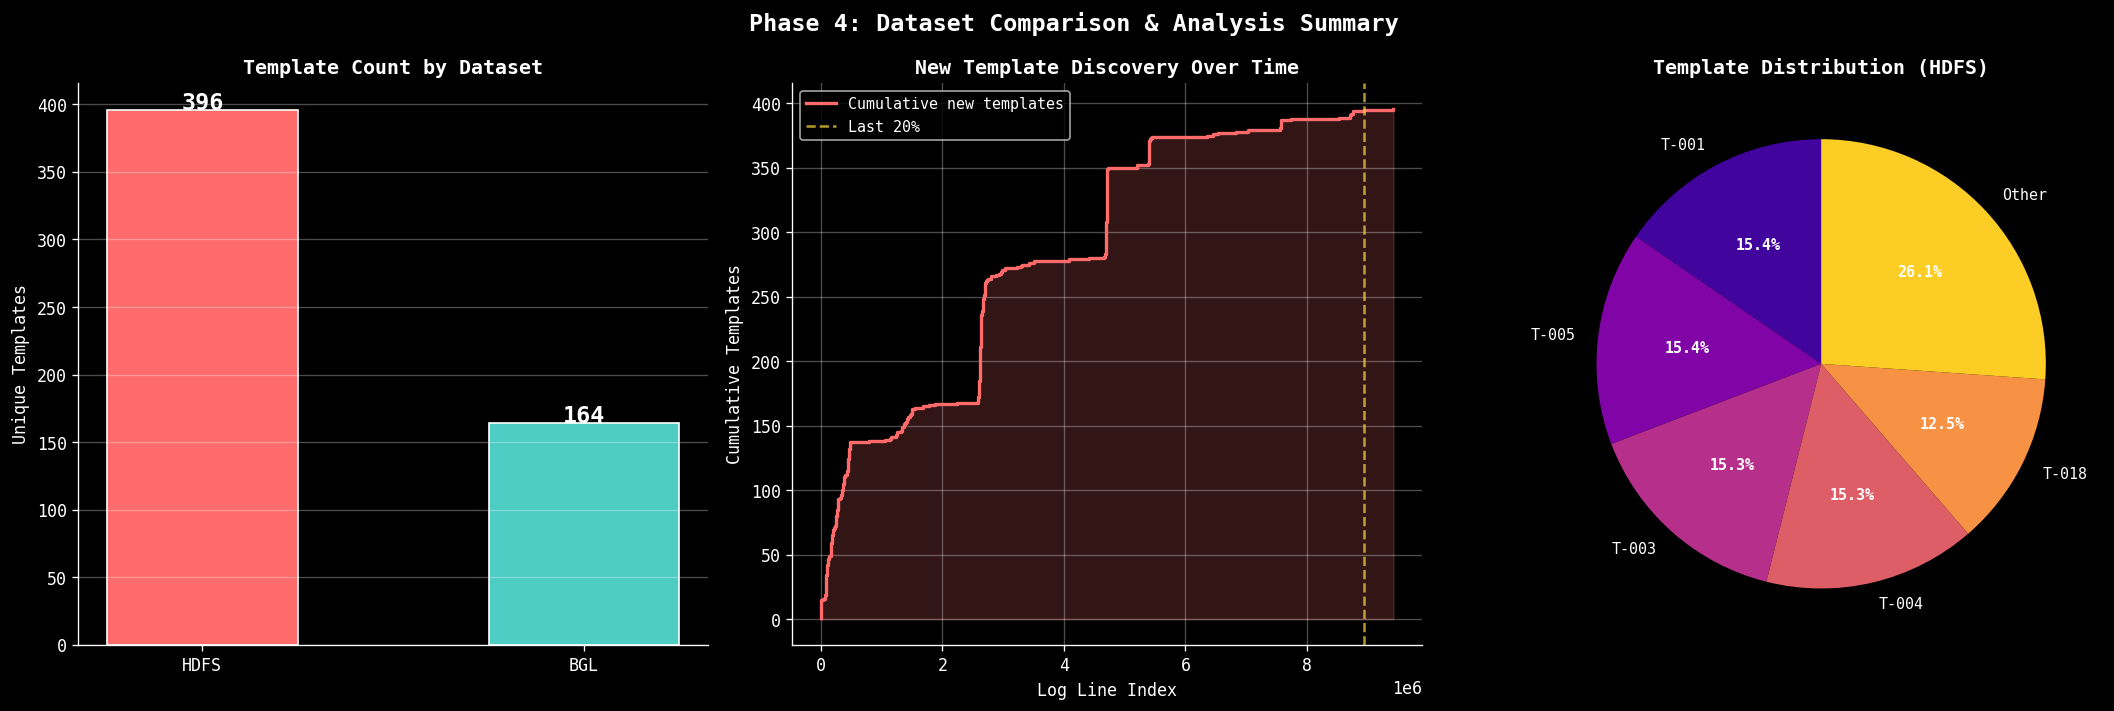

 Saved: assets/plot_phase4_summary.png


In [28]:
# ── 4.5 Final Summary Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 4: Dataset Comparison & Analysis Summary', fontsize=14, fontweight='bold')

# Plot 1: Dataset comparison
ax = axes[0]
datasets = ['HDFS', 'BGL']
tmpl_counts_compare = [result_hdfs['templates'], result_bgl['templates']]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax.bar(datasets, tmpl_counts_compare, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, tmpl_counts_compare):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold', fontsize=14)
ax.set_ylabel('Unique Templates')
ax.set_title('Template Count by Dataset', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Plot 2: New template creation timeline
ax2 = axes[1]
if new_template_log:
    new_tmpl_lines = [e['line_index'] for e in new_template_log]
    new_tmpl_cumsum = list(range(1, len(new_tmpl_lines) + 1))
    ax2.step(new_tmpl_lines, new_tmpl_cumsum, where='post',
             color='#FF6B6B', linewidth=2, label='Cumulative new templates')
    ax2.fill_between(new_tmpl_lines, new_tmpl_cumsum, step='post', alpha=0.2, color='#FF6B6B')
    # Mark last 20% as "recent window"
    cutoff_line = int(len(raw_lines) * 0.8)
    ax2.axvline(x=cutoff_line, color='#FFD93D', linestyle='--', alpha=0.7, label='Last 20%')
ax2.set_xlabel('Log Line Index')
ax2.set_ylabel('Cumulative Templates')
ax2.set_title('New Template Discovery Over Time', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Plot 3: Top template breakdown pie
ax3 = axes[2]
top5_ids   = [row['template_id'] for _, row in templates_df.head(5).iterrows()]
top5_cnts  = [row['count'] for _, row in templates_df.head(5).iterrows()]
other_cnt  = templates_df.iloc[5:]['count'].sum() if len(templates_df) > 5 else 0
pie_labels = [f'T-{tid:03d}' for tid in top5_ids] + (['Other'] if other_cnt > 0 else [])
pie_sizes  = top5_cnts + ([other_cnt] if other_cnt > 0 else [])
pie_colors = list(plt.cm.plasma(np.linspace(0.1, 0.9, len(pie_labels))))
wedges, texts, autotexts = ax3.pie(
    pie_sizes, labels=pie_labels, autopct='%1.1f%%',
    colors=pie_colors, startangle=90,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax3.set_title('Template Distribution (HDFS)', fontweight='bold')

plt.tight_layout()
plt.savefig(ASSETS_DIR / 'plot_phase4_summary.png', dpi=120, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print(" Saved: assets/plot_phase4_summary.png")